# ClimateGuard AI v3.0 - Heatwave Prediction

This notebook covers training ML models for heatwave prediction.  

## 1. Import Libraries

In [1]:
## 2. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import joblib

# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))

from src.models.heatwave_prediction import HeatwavePredictor
from src.models.model_evaluation import ModelEvaluator

# Ensure plots are displayed inline
%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Climate Zones Data

In [2]:
# Load data from climate profiling step
df = pd.read_csv('../data/processed/06_climate_zones.csv')
print(f"Data loaded: {df.shape}")
print(f"Columns: {len(df.columns)}")

Data loaded: (119398, 68)
Columns: 68


## 3. Prepare Features and Target for Heatwave Prediction

In [3]:
# Select numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target and cluster columns from features
feature_cols = [col for col in numerical_cols if 'climate_zone' not in col]

# Create target: temperature > 35°C (heatwave threshold)
if 'temperature' in df.columns:
    df['heatwave_target'] = (df['temperature'] > 35).astype(int)
    y = df['heatwave_target']
    X = df[feature_cols].fillna(0)
else:
    print("Temperature column not found")
    y = None
    X = None

print(f"Features: {len(X.columns)}")
print(f"Target distribution:")
print(y.value_counts())
print(f"\nHeatwave percentage: {y.mean() * 100:.2f}%")

Features: 42
Target distribution:
heatwave_target
0    119041
1       357
Name: count, dtype: int64

Heatwave percentage: 0.30%


## 4. Initialize Heatwave Predictor

In [4]:
predictor = HeatwavePredictor(X, y)
print("Heatwave predictor initialized")

Heatwave predictor initialized


## 5. Train Logistic Regression

In [5]:
print("Training Logistic Regression...")
lr_metrics = predictor.train_logistic_regression(C=1.0, max_iter=1000)
print(f"Accuracy: {lr_metrics['accuracy']:.4f}")
print(f"F1 Score: {lr_metrics['f1_score']:.4f}")
print(f"ROC AUC: {lr_metrics['roc_auc']:.4f}")

Training Logistic Regression...


INFO:src.models.heatwave_prediction:Data preprocessed and split
INFO:src.models.heatwave_prediction:Logistic Regression trained - Accuracy: 0.9995


Accuracy: 0.9995
F1 Score: 0.9091
ROC AUC: 0.9999


## 6. Train Random Forest

In [6]:
print("Training Random Forest...")
rf_metrics = predictor.train_random_forest(n_estimators=100, max_depth=10)
print(f"Accuracy: {rf_metrics['accuracy']:.4f}")
print(f"F1 Score: {rf_metrics['f1_score']:.4f}")
print(f"ROC AUC: {rf_metrics['roc_auc']:.4f}")

Training Random Forest...


INFO:src.models.heatwave_prediction:Data preprocessed and split
INFO:src.models.heatwave_prediction:Random Forest trained - Accuracy: 1.0000


Accuracy: 1.0000
F1 Score: 1.0000
ROC AUC: 1.0000


## 7. Train Gradient Boosting

In [7]:
print("Training Gradient Boosting...")
gb_metrics = predictor.train_gradient_boosting(n_estimators=100, learning_rate=0.1)
print(f"Accuracy: {gb_metrics['accuracy']:.4f}")
print(f"F1 Score: {gb_metrics['f1_score']:.4f}")
print(f"ROC AUC: {gb_metrics['roc_auc']:.4f}")

Training Gradient Boosting...


INFO:src.models.heatwave_prediction:Data preprocessed and split
INFO:src.models.heatwave_prediction:Gradient Boosting trained - Accuracy: 1.0000


Accuracy: 1.0000
F1 Score: 1.0000
ROC AUC: 1.0000


## 8. Select Best Model

In [8]:
best_model = predictor.select_best_model(metric='f1_score')
print(f"Best model selected: {best_model}")

INFO:src.models.heatwave_prediction:Best model selected: random_forest


Best model selected: random_forest


## 9. Print Model Training Report

In [9]:
predictor.print_report()

HEATWAVE PREDICTION MODEL REPORT

LOGISTIC_REGRESSION:
  Accuracy: 0.9995
  Precision: 0.9836
  Recall: 0.8451
  F1 Score: 0.9091
  ROC AUC: 0.9999

RANDOM_FOREST:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  ROC AUC: 1.0000
  Top 5 Feature Importances:
    temperature: 0.4983
    temp_rolling_7d: 0.1379
    pressure: 0.0824
    cumulative_rainfall: 0.0569
    dew_point: 0.0427

GRADIENT_BOOSTING:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  ROC AUC: 1.0000
  Top 5 Feature Importances:
    temperature: 1.0000
    sulphur_dioxide: 0.0000
    latitude: 0.0000
    longitude: 0.0000
    wind_mph: 0.0000

Best Model: random_forest



## 10. Evaluate Best Model

In [10]:
# Get predictions from best model
y_pred = predictor.best_model.predict(predictor.X_test)
y_pred_proba = predictor.best_model.predict_proba(predictor.X_test)[:, 1]

# Evaluate
evaluator = ModelEvaluator(predictor.y_test, y_pred, y_pred_proba)
evaluator.generate_evaluation_report()
evaluator.print_report()

MODEL EVALUATION REPORT

CLASSIFICATION METRICS:
  Accuracy: 0.0186
  Precision (weighted): 0.9970
  Recall (weighted): 0.0186
  F1 Score (weighted): 0.0307
  Precision (binary): 0.0030
  Recall (binary): 1.0000
  F1 Score (binary): 0.0060
  ROC AUC: 0.4742

CONFUSION MATRIX:
  [372, 23437]
  [0, 71]



## 11. Plot Confusion Matrix

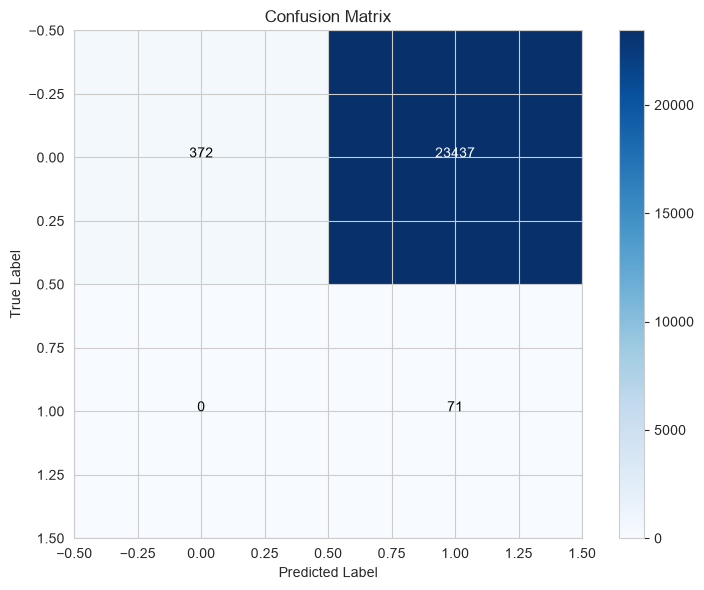

INFO:src.models.model_evaluation:Confusion matrix displayed


Confusion matrix displayed


In [11]:
## 11. Plot Confusion Matrix
evaluator.plot_confusion_matrix()
print("Confusion matrix displayed")

## 12. Plot ROC Curve

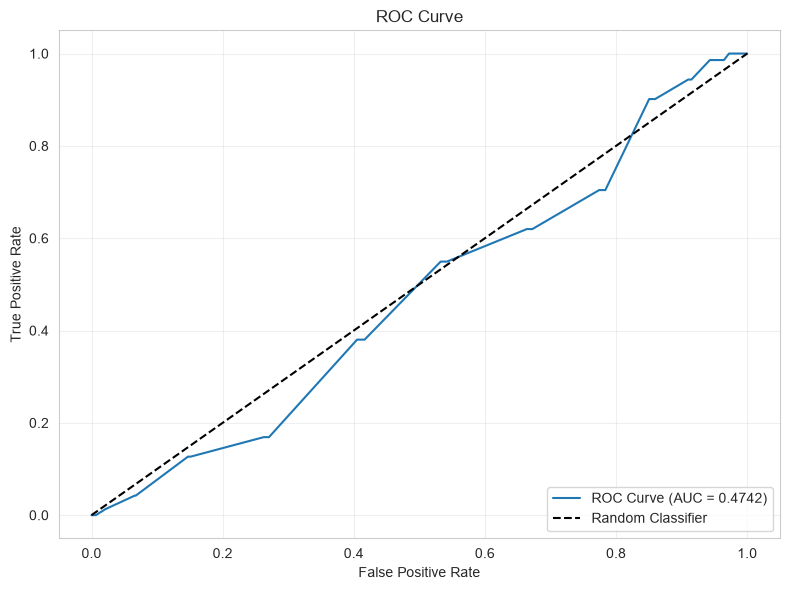

INFO:src.models.model_evaluation:ROC curve displayed


ROC curve displayed


In [12]:
## 12. Plot ROC Curve
evaluator.plot_roc_curve()
print("ROC curve displayed")

## 13. Feature Importance

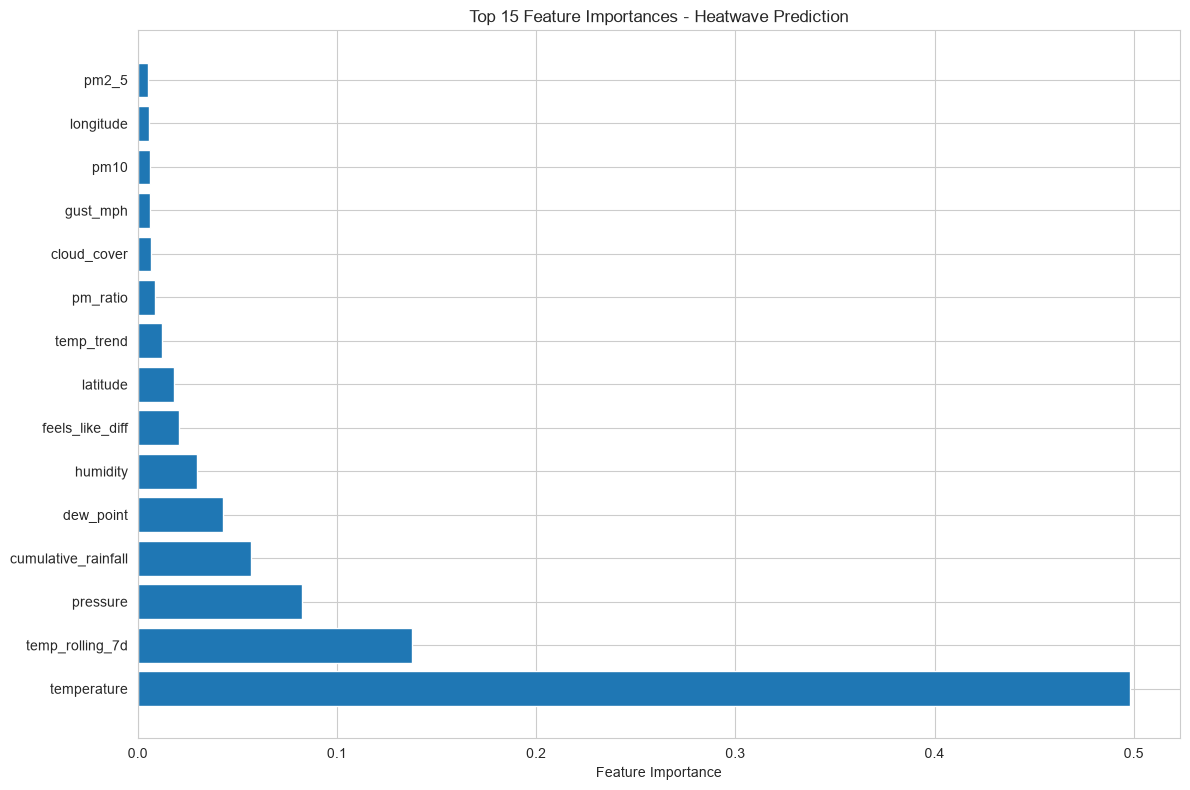

Feature importance plot displayed


In [13]:
if predictor.best_model_name in ['random_forest', 'gradient_boosting']:
    report = predictor.get_model_report()
    if 'feature_importance' in report[predictor.best_model_name]:
        importance = report[predictor.best_model_name]['feature_importance']
        
        # Plot feature importance
        plt.figure(figsize=(12, 8))
        sorted_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:15]
        features, scores = zip(*sorted_features)
        plt.barh(range(len(features)), scores)
        plt.yticks(range(len(features)), features)
        plt.xlabel('Feature Importance')
        plt.title('Top 15 Feature Importances - Heatwave Prediction')
        plt.tight_layout()
        plt.show()
        print("Feature importance plot displayed")

## 14. Save Best Model

In [14]:
# Save the best model
predictor.save_model(predictor.best_model_name, '../trained_models/heatwave_model.pkl')
print(f"Best model saved to ../trained_models/heatwave_model.pkl")

INFO:src.models.heatwave_prediction:Model random_forest saved to ../trained_models/heatwave_model.pkl


Best model saved to ../trained_models/heatwave_model.pkl


## 15. Test Prediction on Sample Data

In [15]:
# Test on a sample
sample = X.iloc[[0]]
prediction, probability = predictor.predict(sample)

print(f"Sample prediction: {prediction[0]}")
print(f"Heatwave probability: {probability[0]:.4f}")
print(f"Actual: {y.iloc[0]}")

Sample prediction: 0
Heatwave probability: 0.0000
Actual: 0


## Summary

In this notebook, we:
1. Loaded the climate zones data
2. Prepared features and target for heatwave prediction (temperature > 35°C)
3. Trained Logistic Regression model
4. Trained Random Forest model
5. Trained Gradient Boosting model
6. Selected the best model based on F1 score
7. Evaluated the best model
8. Generated confusion matrix and ROC curve
9. Analyzed feature importance
10. Saved the best model for deployment

Next: Climate Risk Score